In [1]:
import pymc as pm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import arviz as az
import pickle
from scipy import stats

import covid19_inference.covid19_inference as cov19

# increase plt fontsize
plt.rcParams.update({'font.size': 20})

from matplotlib import lines, patches

In [22]:
# colormap for plots
from matplotlib import colormaps
colormap = colormaps['viridis']

color_m_base = colormap(0.0)
color_m_obs = colormap(0.2)
color_m = colormap(0.2)

color_R = colormap(0.4)
color_del_m_R = colormap(0.4)
#color_m_R = colormap(0.4)

color_C = colormap(0.6)
color_del_m_C = colormap(0.6)
#color_m_C = colormap(0.7)

color_ICU = colormap(0.8)
color_del_m_ICU = colormap(0.8)
#color_m_ICU = colormap(1.0)

# Input data

## Mobility

In [3]:
path_mobility = "data/mobility/mobilityData_OverviewBL_weekly.csv"
mobility_df = pd.read_csv(path_mobility, parse_dates=True, index_col=0, delimiter=";")
mobility_df = mobility_df[mobility_df["BundeslandID"] == "Deutschland"]
mobility_df["week"] = mobility_df.index.isocalendar().week
#display(mobility_df)

In [4]:
# get dates
mobility_dates = mobility_df.index.values
mobility_dates_2020 = mobility_dates[mobility_dates < np.datetime64('2020-12-24')]
mobility_dates_2020 = mobility_dates_2020[mobility_dates_2020 > np.datetime64('2020-03-15')]
mobility_dates_2022 = mobility_dates[mobility_dates < np.datetime64('2022-12-24')]
mobility_dates_2022_shortened = mobility_dates_2022[-len(mobility_dates_2020):]

# get mobility data
mobility_df_2020 = mobility_df.filter(items=mobility_dates_2020, axis=0)
mobility_df_2022 = mobility_df.filter(items=mobility_dates_2022_shortened, axis=0)

In [5]:
mobility_data_2020 = mobility_df_2020["outOfHomeDuration"].to_xarray()
mobility_data_2022 = mobility_df_2022["outOfHomeDuration"].to_xarray()

### Plot

Text(0, 0.5, 'Difference in out of home\nduration $m_{2022} - m_{2020}$ [h]')

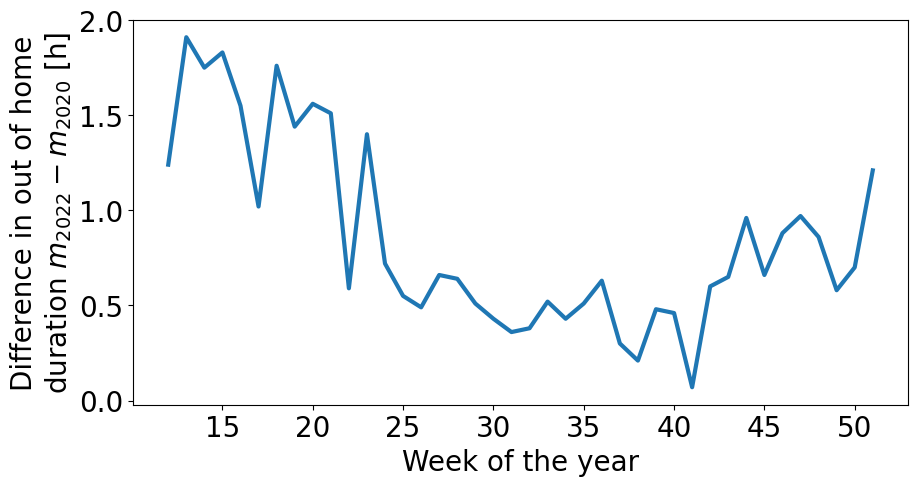

In [6]:
# plot mobility data
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(mobility_df_2020["week"], mobility_df_2022["outOfHomeDuration"].values-mobility_df_2020["outOfHomeDuration"].values, linewidth=3)
#ax.legend()
ax.set_xlabel("Week of the year") # THIS IS NOT COMPLETELY CORRECT AS 2022 IS ONLY 51 WEEKS LONG
ax.set_ylabel(f"Difference in out of home\nduration $m_{{2022}} - m_{{2020}}$ [h]")

Text(0, 0.5, 'Difference in out of home\nduration $m_{2020} - m_{2022}$ [h]')

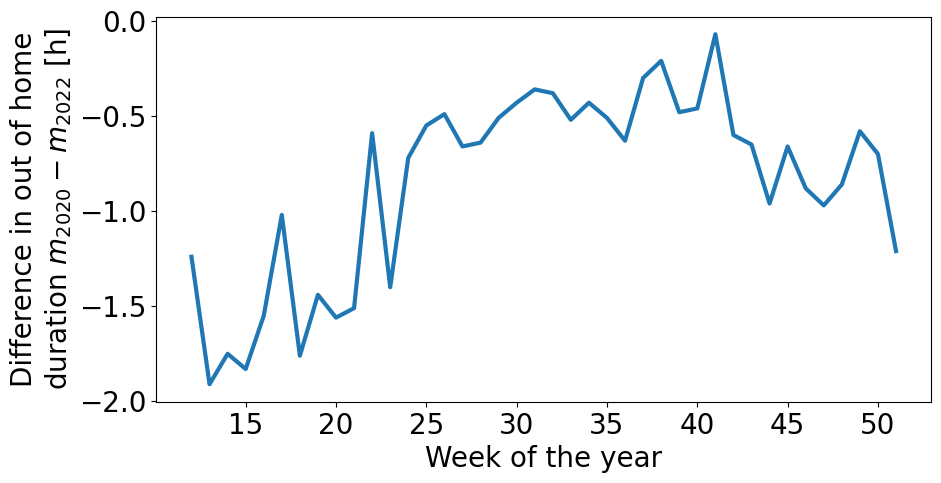

In [7]:
# plot mobility data
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(mobility_df_2020["week"], mobility_df_2020["outOfHomeDuration"].values-mobility_df_2022["outOfHomeDuration"].values, linewidth=3)
#ax.legend()
ax.set_xlabel("Week of the year") # THIS IS NOT COMPLETELY CORRECT AS 2022 IS ONLY 51 WEEKS LONG
ax.set_ylabel(f"Difference in out of home\nduration $m_{{2020}} - m_{{2022}}$ [h]")

## Helper functions

In [6]:
def cut_off_before_monday(df):
    while df.index[0].dayofweek != 0:
        df = df[1:]
    return df

# weekly average placed on Sunday
def weekly_formatting(df_in, dates_in):
    df = cut_off_before_monday(df_in)
    df = df.resample('7D').mean()
    df.index = df.index + pd.Timedelta(days=6)
    return df.filter(items=dates_in, axis=0)

## Effective Reproduction Number

In [44]:
path_R = "data/R/Germany/R_eff_Germany.csv"
R_df = pd.read_csv(path_R, index_col=1, parse_dates=True)

In [45]:
# weekly average placed on Sunday
R_df_weekly_shortened = weekly_formatting(R_df, mobility_dates_2020)
R_data = R_df_weekly_shortened["R_eff median"].to_xarray()

# plot R data
#R_data.plot()

## Our World in Data

In [7]:
owid = cov19.data_retrieval.OWD()
owid.download_all_available_data()

INFO     [covid19_inference.covid19_inference.data_retrieval.retrieval] Successfully loaded OurWorldinData.csv.gz from /tmp/covid19_data/, skipping download.


In [8]:
owid.data.columns

Index(['iso_code', 'continent', 'country', 'total_cases', 'new_cases',
       'new_cases_smoothed', 'total_deaths', 'new_deaths',
       'new_deaths_smoothed', 'total_cases_per_million',
       'new_cases_per_million', 'new_cases_smoothed_per_million',
       'total_deaths_per_million', 'new_deaths_per_million',
       'new_deaths_smoothed_per_million', 'reproduction_rate', 'icu_patients',
       'icu_patients_per_million', 'hosp_patients',
       'hosp_patients_per_million', 'weekly_icu_admissions',
       'weekly_icu_admissions_per_million', 'weekly_hosp_admissions',
       'weekly_hosp_admissions_per_million', 'total_tests', 'new_tests',
       'total_tests_per_thousand', 'new_tests_per_thousand',
       'new_tests_smoothed', 'new_tests_smoothed_per_thousand',
       'positive_rate', 'tests_per_case', 'tests_units', 'total_vaccinations',
       'people_vaccinated', 'people_fully_vaccinated', 'total_boosters',
       'new_vaccinations', 'new_vaccinations_smoothed',
       'total_vacc

### Hospitalisation

In [13]:
H_data = owid._filter(
    value = "weekly_hosp_admissions_per_million", 
    country="Germany", 
    )
H_data = weekly_formatting(H_data, mobility_dates_2020)
H_data = H_data.to_xarray()
H_data

<xarray.DataArray 'weekly_hosp_admissions_per_million' (date: 40)>
array([ 14.27014286,  42.141     ,  71.16657143,  66.51942857,
        47.80614286,  35.52157143,  21.77914286,  14.25657143,
        11.14485714,   7.423     ,   5.72485714,   4.102     ,
         3.47514286,   3.77971429,   3.85342857,   3.37057143,
         3.08471429,   3.374     ,   4.02828571,   4.26485714,
         4.83057143,   5.12542857,   5.34657143,   4.83057143,
         4.52885714,   5.134     ,   7.04942857,   8.82971429,
         9.949     ,  14.60442857,  23.14128571,  37.61214286,
        60.98457143,  78.934     ,  86.26814286,  96.51828571,
        99.75      , 104.82557143, 122.48685714, 144.78685714])
Coordinates:
  * date     (date) datetime64[ns] 2020-03-22 2020-03-29 ... 2020-12-20

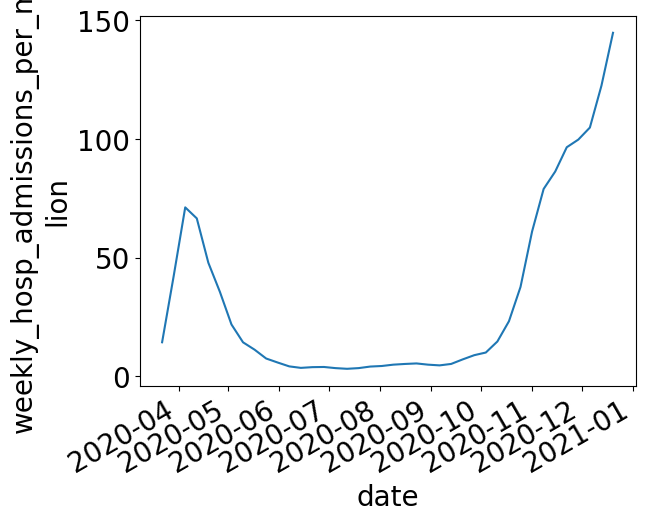

In [14]:
H_data.plot()

### ICU

In [24]:
ICU_data = owid._filter(
    value = "icu_patients_per_million", 
    country="Germany", 
    #data_begin=mobility_dates_2020[0], 
    #data_end=mobility_dates_2020[-1]
    )
ICU_data = weekly_formatting(ICU_data, mobility_dates_2020)
ICU_data = ICU_data.to_xarray()
#ICU_data

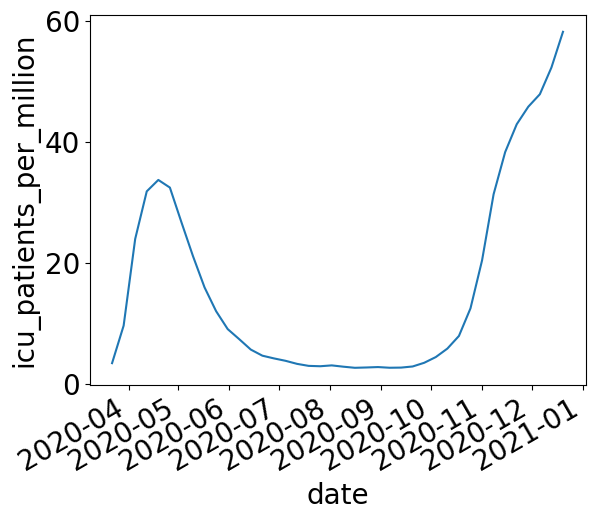

In [25]:
# plot ICU data
ICU_data.plot()

### Cases

In [8]:
case_data = owid._filter(
    value = "new_cases_smoothed_per_million", 
    country="Germany", 
    )
case_data = weekly_formatting(case_data, mobility_dates_2020)
case_data = case_data.to_xarray()

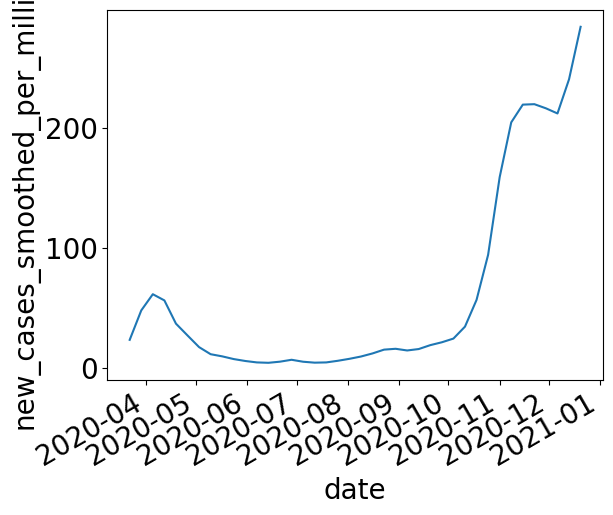

In [9]:
# plot case data
case_data.plot()

## Visualise and compare

(12.0, 51.0)

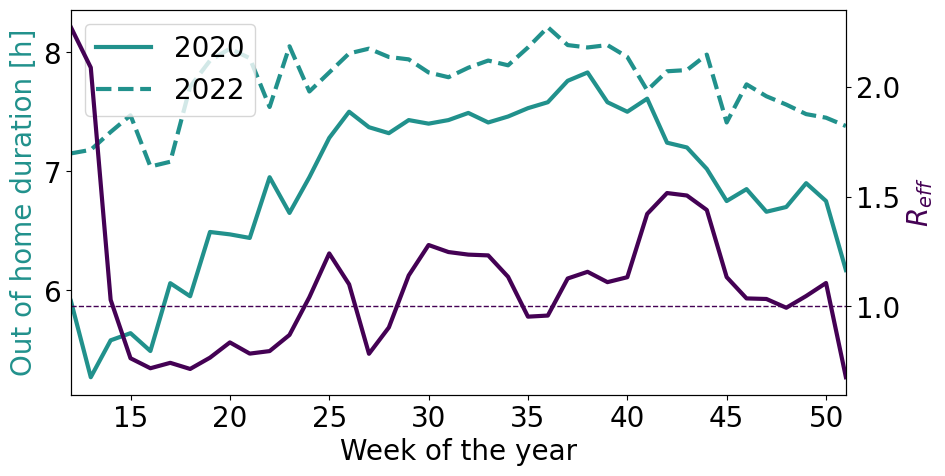

In [10]:
# plot mobility and R data
color_R = colormap(0)
color_m = colormap(0.5)

min_x = mobility_df_2020["week"].min()
max_x = mobility_df_2020["week"].max()

fig, ax = plt.subplots(figsize=(10, 5))
ax_R = ax.twinx()
ax.plot(mobility_df_2020["week"], mobility_df_2020["outOfHomeDuration"], label="2020", linewidth=3, color=color_m_R)
ax.plot(mobility_df_2020["week"], mobility_df_2022["outOfHomeDuration"], label="2022", linewidth=3, color=color_m_base, linestyle="--")
ax_R.plot(mobility_df_2020["week"], R_df_weekly_shortened["R_eff median"], linewidth=3, color=color_R)
ax_R.hlines(1, min_x, max_x, color=color_R, linestyle="--", linewidth=1)
ax.legend(loc="upper left")
ax.set_xlabel("Week of the year") # THIS IS NOT COMPLETELY CORRECT AS 2022 IS ONLY 51 WEEKS LONG
ax.set_ylabel("Out of home duration [h]", color=color_m)
ax_R.set_ylabel(f"$R_{{eff}}$", color=color_R)
ax.set_xlim(min_x, max_x)

# Bayesian Inference

## Cases model

In [10]:
n = case_data.shape[0]
with pm.Model() as C_model:
    # define data
    m_base_data = pm.ConstantData('m_base', mobility_data_2022, dims=['time'])
    cases_data = pm.ConstantData('cases', case_data, dims=['time'])

    # define priors
    c = pm.Normal('c', mu=0.001, sigma=0.001)
    mu_C = pm.LogNormal('mu_C', mu=0.8, sigma=0.2)
    sigma_C = pm.LogNormal('sigma_C', mu=0.3, sigma=0.1)
    model_error = pm.HalfCauchy('sigma', beta=0.5)

    C_model.sim_len = n
    C_model.diff_data_sim = 16
    risk =  cov19.model.delay_cases(            
        cases=cases_data,
        delay_kernel="gamma",
        median_delay=mu_C,
        scale_delay=sigma_C,
        )

    del_m_C = - c * risk
    del_m_C = pm.Deterministic('del_m_C', del_m_C)

    # define likelihood
    m_C = pm.Deterministic("m_C", m_base_data + del_m_C)
    likelihood = pm.Normal('likelihood', mu=m_C, sigma=model_error, observed=mobility_data_2020)

INFO     [covid19_inference.covid19_inference.model.delay] Delaying cases


In [23]:
# inference
C_trace = pm.sample(model=C_model, draws=200, tune=200, cores=4, chains=4)
with C_model:
    pm.compute_log_likelihood(C_trace)

# Saving the results
tag = "C_model_test"	
# Save the trace
path = f"results/raw/trace_{tag}.pickle"
with open(path, "wb") as inference_file:
    pickle.dump(C_trace, inference_file)

Only 200 samples in chain.
WARNING  [pymc] Only 200 samples in chain.
Auto-assigning NUTS sampler...
INFO     [pymc] Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
INFO     [pymc] Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
INFO     [pymc] Multiprocess sampling (4 chains in 4 jobs)
NUTS: [c, mu_C, sigma_C, sigma]
INFO     [pymc] NUTS: [c, mu_C, sigma_C, sigma]


Sampling 4 chains for 200 tune and 200 draw iterations (800 + 800 draws total) took 6 seconds.
INFO     [pymc] Sampling 4 chains for 200 tune and 200 draw iterations (800 + 800 draws total) took 6 seconds.
INFO     [pymc] Sampling 4 chains for 200 tune and 200 draw iterations (800 + 800 draws total) took 6 seconds.


## R model

In [46]:
n = R_data.shape[0]
with pm.Model() as R_model:
    # define data
    m_base_data = pm.ConstantData('m_base', mobility_data_2022, dims=['time'])
    R_eff_data = pm.ConstantData('R_eff', R_data, dims=['time'])

    # define priors
    a = pm.Normal('a', mu=1, sigma=0.1)
    mu_R = pm.LogNormal('mu_R', mu=0.8, sigma=0.2)
    sigma_R = pm.LogNormal('sigma_R', mu=0.3, sigma=0.1)
    model_error = pm.HalfCauchy('sigma', beta=0.5)

    # NEED TO UNDERSTAND THE KERNEL BETTER
    R_model.sim_len = n
    R_model.diff_data_sim = 16
    risk =  cov19.model.delay_cases(            
        cases=R_eff_data,
        delay_kernel="gamma",
        median_delay=mu_R,
        scale_delay=sigma_R,
        )

    del_m_R = - a * risk
    del_m_R = pm.Deterministic('del_m_R', del_m_R)

    # define likelihood
    m_R = pm.Deterministic("m_R", m_base_data + del_m_R)
    likelihood = pm.Normal('likelihood', mu=m_R, sigma=model_error, observed=mobility_data_2020)

INFO     [covid19_inference.covid19_inference.model.delay] Delaying cases


In [14]:
# inference
R_trace = pm.sample(model=R_model, draws=200, tune=200, cores=1, chains=4)
with R_model:
    pm.compute_log_likelihood(R_trace)

# Saving the results
tag = "R_model_test"	
# Save the trace
path = f"results/raw/trace_{tag}.pickle"
with open(path, "wb") as inference_file:
    pickle.dump(R_trace, inference_file)

Only 200 samples in chain.
WARNING  [pymc] Only 200 samples in chain.
Auto-assigning NUTS sampler...
INFO     [pymc] Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
INFO     [pymc] Initializing NUTS using jitter+adapt_diag...


Sampling 4 chains for 200 tune and 200 draw iterations (800 + 800 draws total) took 2836 seconds.
INFO     [pymc] Sampling 4 chains for 200 tune and 200 draw iterations (800 + 800 draws total) took 2836 seconds.
INFO     [pymc] Sampling 4 chains for 200 tune and 200 draw iterations (800 + 800 draws total) took 2836 seconds.


## ICU model

In [26]:
n = ICU_data.shape[0]
with pm.Model() as ICU_model:
    # define data
    m_base_data = pm.ConstantData('m_base', mobility_data_2022, dims=['time'])
    icu_data = pm.ConstantData('ICU', ICU_data, dims=['time'])

    # define priors
    b = pm.Normal('b', mu=0.08, sigma=0.02)
    mu_ICU = pm.LogNormal('mu_ICU', mu=1, sigma=0.5)
    sigma_ICU = pm.LogNormal('sigma_ICU', mu=0.5, sigma=0.1)
    model_error = pm.HalfCauchy('sigma', beta=0.5)

    # NEED TO UNDERSTAND THE KERNEL BETTER
    #R_model.shape_of_regions = 1
    ICU_model.sim_len = n
    ICU_model.diff_data_sim = 16
    risk = cov19.model.delay_cases(            
        cases=icu_data,
        delay_kernel="gamma",
        median_delay=mu_ICU,
        scale_delay=sigma_ICU,
        )

    del_m_ICU = - b * risk
    del_m_ICU = pm.Deterministic('del_m_ICU', del_m_ICU)

    # define likelihood
    m_ICU = pm.Deterministic("m_ICU", m_base_data + del_m_ICU)
    likelihood = pm.Normal('likelihood', mu=m_ICU, sigma=model_error, observed=mobility_data_2020)

INFO     [covid19_inference.covid19_inference.model.delay] Delaying cases


In [32]:
# inference
ICU_trace = pm.sample(model=ICU_model, draws=200, tune=200, cores=1, chains=4)

# Saving the results
# Save the trace
tag = "ICU_model_test"	
path = f"results/raw/trace_{tag}.pickle"
with open(path, "wb") as inference_file:
    pickle.dump(ICU_trace, inference_file)

Only 200 samples in chain.
WARNING  [pymc] Only 200 samples in chain.
c:\Users\iftek\mambaforge\envs\feedback_inference\lib\site-packages\multipledispatch\dispatcher.py:27: AmbiguityWarning: 
Ambiguities exist in dispatched function _unify

The following signatures may result in ambiguous behavior:
	[object, ConstrainedVar, Mapping], [ConstrainedVar, Var, Mapping]
	[ConstrainedVar, object, Mapping], [object, ConstrainedVar, Mapping]
	[ConstrainedVar, object, Mapping], [object, ConstrainedVar, Mapping]
	[ConstrainedVar, Var, Mapping], [object, ConstrainedVar, Mapping]


Consider making the following additions:

@dispatch(ConstrainedVar, ConstrainedVar, Mapping)
def _unify(...)

@dispatch(ConstrainedVar, ConstrainedVar, Mapping)
def _unify(...)

@dispatch(ConstrainedVar, ConstrainedVar, Mapping)
def _unify(...)

@dispatch(ConstrainedVar, ConstrainedVar, Mapping)
def _unify(...)
  warn(warning_text(dispatcher.name, ambiguities), AmbiguityWarning)
Auto-assigning NUTS sampler...
INFO     [p

Sampling 4 chains for 200 tune and 200 draw iterations (800 + 800 draws total) took 13 seconds.
INFO     [pymc] Sampling 4 chains for 200 tune and 200 draw iterations (800 + 800 draws total) took 13 seconds.


## R + cases model

In [84]:
n = R_data.shape[0]
with pm.Model() as RC_model:
    RC_model.sim_len = n
    RC_model.diff_data_sim = 16

    # define data
    m_base_data = pm.ConstantData('m_base', mobility_data_2022, dims=['time'])
    R_eff_data = pm.ConstantData('R_eff', R_data, dims=['time'])
    cases_data = pm.ConstantData('cases', case_data, dims=['time'])

    # define priors
    a = pm.Normal('a', mu=0.8, sigma=0.1)
    mu_R = pm.LogNormal('mu_R', mu=0.8, sigma=0.2)
    sigma_R = pm.LogNormal('sigma_R', mu=0.3, sigma=0.1)
    c = pm.Normal('c', mu=0.001, sigma=0.001)
    mu_C = pm.LogNormal('mu_C', mu=0.8, sigma=0.2)
    sigma_C = pm.LogNormal('sigma_C', mu=0.3, sigma=0.1)
    model_error = pm.HalfCauchy('sigma', beta=0.5)

    # R model
    R_risk =  cov19.model.delay_cases(            
        cases=R_eff_data,
        delay_kernel="gamma",
        median_delay=mu_R,
        scale_delay=sigma_R,
        )
    del_m_R = - a * R_risk
    del_m_R = pm.Deterministic('del_m_R', del_m_R)

    # ICU model
    C_risk = cov19.model.delay_cases(            
        cases=cases_data,
        delay_kernel="gamma",
        median_delay=mu_C,
        scale_delay=sigma_C,
        )
    del_m_C = - c * C_risk
    del_m_C = pm.Deterministic('del_m_C', del_m_C)

    # define likelihood
    m = pm.Deterministic("m", m_base_data + del_m_R + del_m_C)
    likelihood = pm.Normal('likelihood', mu=m, sigma=model_error, observed=mobility_data_2020)

INFO     [covid19_inference.covid19_inference.model.delay] Delaying cases
INFO     [covid19_inference.covid19_inference.model.delay] Delaying cases


In [85]:
# inference
RC_trace = pm.sample(model=RC_model, draws=200, tune=200, cores=1, chains=4)

# ## Saving the results
# Save the trace.
tag = "R+cases_model_test"	
path = f"results/raw/trace_{tag}.pickle"
with open(path, "wb") as inference_file:
    pickle.dump(RC_trace, inference_file)

Only 200 samples in chain.
WARNING  [pymc] Only 200 samples in chain.
Auto-assigning NUTS sampler...
INFO     [pymc] Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
INFO     [pymc] Initializing NUTS using jitter+adapt_diag...


Sampling 4 chains for 200 tune and 200 draw iterations (800 + 800 draws total) took 36 seconds.
INFO     [pymc] Sampling 4 chains for 200 tune and 200 draw iterations (800 + 800 draws total) took 36 seconds.


## R + ICU model

In [51]:
n = ICU_data.shape[0]
with pm.Model() as joint_model:
    joint_model.sim_len = n
    joint_model.diff_data_sim = 16

    # define data
    m_base_data = pm.ConstantData('m_base', mobility_data_2022, dims=['time'])
    R_eff_data = pm.ConstantData('R_eff', R_data, dims=['time'])
    icu_data = pm.ConstantData('ICU', ICU_data, dims=['time'])

    # define priors
    a = pm.Normal('a', mu=0.8, sigma=0.1)
    mu_R = pm.LogNormal('mu_R', mu=0.8, sigma=0.2)
    sigma_R = pm.LogNormal('sigma_R', mu=0.3, sigma=0.1)
    b = pm.Normal('b', mu=0.05, sigma=0.01)
    mu_ICU = pm.LogNormal('mu_ICU', mu=0.8, sigma=0.2)
    sigma_ICU = pm.LogNormal('sigma_ICU', mu=0.3, sigma=0.1)
    model_error = pm.HalfCauchy('sigma', beta=0.5)

    # R model
    R_risk =  cov19.model.delay_cases(            
        cases=R_eff_data,
        delay_kernel="gamma",
        median_delay=mu_R,
        scale_delay=sigma_R,
        )
    del_m_R = - a * R_risk
    del_m_R = pm.Deterministic('del_m_R', del_m_R)

    # ICU model
    ICU_risk = cov19.model.delay_cases(            
        cases=icu_data,
        delay_kernel="gamma",
        median_delay=mu_ICU,
        scale_delay=sigma_ICU,
        )
    del_m_ICU = - b * ICU_risk
    del_m_ICU = pm.Deterministic('del_m_ICU', del_m_ICU)

    # define likelihood
    m = pm.Deterministic("m", m_base_data + del_m_R + del_m_ICU)
    likelihood = pm.Normal('likelihood', mu=m, sigma=model_error, observed=mobility_data_2020)

INFO     [covid19_inference.covid19_inference.model.delay] Delaying cases
INFO     [covid19_inference.covid19_inference.model.delay] Delaying cases


In [53]:
# inference
joint_trace = pm.sample(model=joint_model, draws=200, tune=200, cores=1, chains=4)

# ## Saving the results
# Save the trace.
tag = "joint_model_test"	
path = f"results/raw/trace_{tag}.pickle"
with open(path, "wb") as inference_file:
    pickle.dump(joint_trace, inference_file)

Only 200 samples in chain.
WARNING  [pymc] Only 200 samples in chain.
WARNING  [pymc] Only 200 samples in chain.
Auto-assigning NUTS sampler...
INFO     [pymc] Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
INFO     [pymc] Initializing NUTS using jitter+adapt_diag...


Sampling 4 chains for 200 tune and 200 draw iterations (800 + 800 draws total) took 28 seconds.
INFO     [pymc] Sampling 4 chains for 200 tune and 200 draw iterations (800 + 800 draws total) took 28 seconds.


# Results

In [11]:
def concatenate_chains_and_draws(xarray_in):
    array = np.array(xarray_in)
    return array.reshape(-1, array.shape[-1])

def plot_timeseries(ax_in, x_in, xarray_in, label_in, color_in):
    array = concatenate_chains_and_draws(xarray_in)
    ax_in.plot(x_in, np.median(array, axis=0), label=label_in, color=color_in, linewidth=3)
    ax_in.fill_between(
                x_in,
                np.percentile(array, q=3, axis=0),
                np.percentile(array, q=97, axis=0),
                alpha=0.5,
                color=color_in,
            )
    
def format_x_axis(ax_in, x_in, last=False):
    # choose number of x ticks
    n_xticks = 6
    # get x tick locations
    xticks = np.linspace(0, len(x_in)-1, n_xticks, dtype=int)
    # get x tick labels
    xticklabels = [x_in[i].strftime("%d %b") for i in xticks]
    # set x ticks
    ax_in.set_xticks([x_in[i]for i in xticks])
    # increase x tick length
    ax_in.tick_params(axis="x", length=10)
    if last:
        # set x tick labels
        ax_in.set_xticklabels(xticklabels)
        ax_in.set_xlabel("Year 2020")
    else:
        # set x tick labels
        ax_in.set_xticklabels([])
    # set x limits
    ax_in.set_xlim(x_in[0], x_in[-1])

In [12]:
# convert dates to datetime
dates = pd.to_datetime(mobility_dates_2020)

## Cases

In [14]:
# load trace from file
tag = "C_model_test"
path = f"results/raw/trace_{tag}.pickle"
with open(path, "rb") as inference_file:
    C_trace = pickle.load(inference_file)

In [15]:
az.summary(C_trace)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
c,0.003,0.001,0.002,0.004,0.000,0.000,615.0,460.0,1.01
mu_C,1.564,0.200,1.235,1.917,0.011,0.008,360.0,444.0,1.00
sigma_C,1.467,0.137,1.226,1.739,0.006,0.004,540.0,581.0,1.00
sigma,0.741,0.096,0.577,0.919,0.004,0.003,504.0,563.0,1.00
del_m_C[0],-0.216,0.056,-0.327,-0.121,0.002,0.002,532.0,490.0,1.01
...,...,...,...,...,...,...,...,...,...
m_C[35],6.931,0.143,6.636,7.167,0.006,0.004,624.0,460.0,1.01
m_C[36],6.861,0.143,6.566,7.098,0.006,0.004,624.0,460.0,1.01
m_C[37],6.781,0.143,6.482,7.015,0.006,0.004,624.0,460.0,1.01
m_C[38],6.751,0.143,6.451,6.986,0.006,0.004,623.0,460.0,1.01


Sampling: [c]
INFO     [pymc] Sampling: [c]
Sampling: [mu_C]
INFO     [pymc] Sampling: [mu_C]
Sampling: [sigma_C]
INFO     [pymc] Sampling: [sigma_C]
Sampling: [sigma]
INFO     [pymc] Sampling: [sigma]


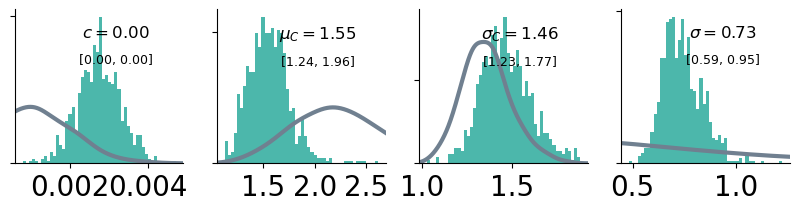

In [16]:
fig, axs = plt.subplots(1, 4, figsize=(10, 2))

cov19.plot.distribution(C_model, C_trace, 'c', dist_math='c', ax=axs[0])
cov19.plot.distribution(C_model, C_trace, 'mu_C', dist_math='\mu_C', ax=axs[1])
cov19.plot.distribution(C_model, C_trace, 'sigma_C', dist_math='\sigma_C', ax=axs[2])
cov19.plot.distribution(C_model, C_trace, 'sigma', dist_math='\sigma', ax=axs[3])

fig.savefig(f"figures/{tag}_distributions.png", dpi=300, bbox_inches="tight")

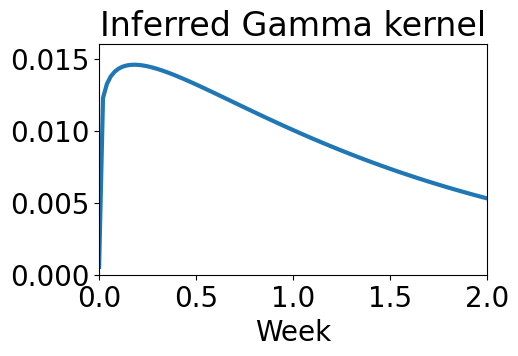

In [17]:
# plot Gamma distribution with inferred mean and standard deviation
fig, ax = plt.subplots(1, 1, figsize=(5, 3))
max_x = 2
x = np.linspace(0, max_x, 100)
y = cov19.model._utility.tt_gamma(x, mu=np.median(C_trace.posterior['mu_C']), sigma=np.median(C_trace.posterior['sigma_C'])).eval()
ax.plot(x, y, linewidth=3)
ax.set_xlabel("Week")
ax.set_title("Inferred Gamma kernel")
ax.set_xlim(0, max_x)
ax.set_ylim(0, 1.1*np.max(y))
fig.savefig(f"figures/{tag}_gamma_kernel.png", dpi=300, bbox_inches="tight")

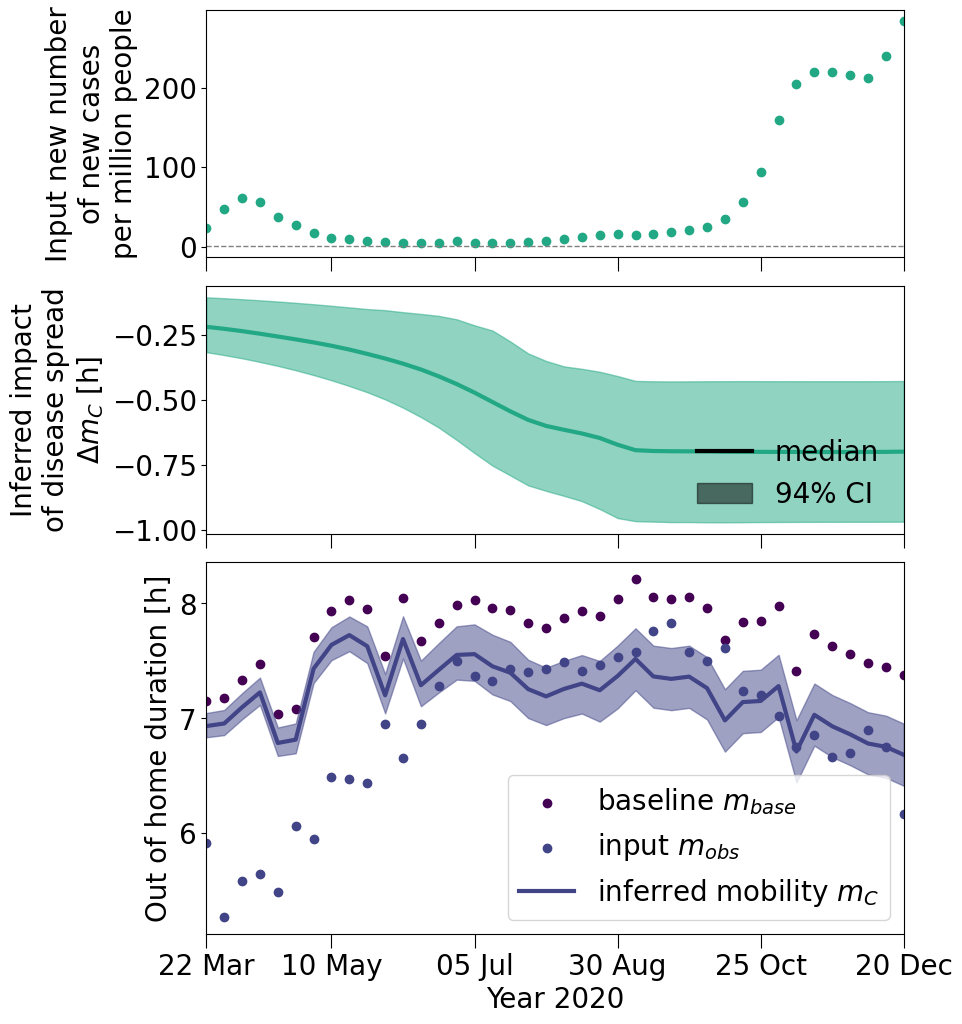

In [23]:
fig, axs = plt.subplots(3, 1, figsize=(9, 12), height_ratios=[2, 2, 3], sharex=True)

# upper plot
ax = axs[0]
ax.scatter(dates, C_trace.constant_data["cases"], color=color_C)
ax.hlines(1, dates[0], dates[-1], linestyle="--", color="grey", linewidth=1)
ax.set_ylabel(f"Input new number\nof new cases\nper million people")
format_x_axis(ax, dates)

# middle plot
ax = axs[1]
plot_timeseries(ax, dates, C_trace.posterior['del_m_C'], "inferred impact of disease spread $\Delta m_C$", color_del_m_C)
format_x_axis(ax, dates)
# set y label
ax.set_ylabel("Inferred impact\nof disease spread\n$\Delta m_C$ [h]")
# create custom legend
## for median line and 94% CI
median_line = lines.Line2D([], [], color='black', linewidth=3, label="median")
ci_94 = patches.Patch(color='black', alpha=0.5, label="94% CI")
## create legend
legend = ax.legend(handles=[median_line, ci_94], loc="lower right", frameon=False)

# lower plot
ax = axs[2]
ax.scatter(dates, C_trace.constant_data["m_base"], label="baseline $m_{base}$", color=color_m_base)
ax.scatter(dates, C_trace.observed_data["likelihood"], label="input $m_{obs}$", color=color_m_obs)
plot_timeseries(ax, dates, C_trace.posterior['m_C'], "inferred mobility $m_C$", color_m)
ax.legend()
format_x_axis(ax, dates, last=True)
# set y label
ax.set_ylabel("Out of home duration [h]")

plt.subplots_adjust(hspace=0.1)

# save figure
plt.savefig(f"figures/overview_{tag}.png", bbox_inches="tight")

## R

In [38]:
# load trace from file
tag = "R_model_test"
path = f"results/raw/trace_{tag}.pickle"
with open(path, "rb") as inference_file:
    R_trace = pickle.load(inference_file)

In [47]:
az.summary(R_trace, var_names=["a", "mu_R", "sigma_R", "sigma"], round_to=2)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
a,0.90,0.06,0.80,1.01,0.00,0.00,836.93,597.70,1.00
mu_R,1.59,0.31,1.13,2.15,0.02,0.02,338.15,156.37,1.02
sigma_R,1.44,0.13,1.20,1.69,0.00,0.00,829.28,641.65,1.00
sigma,0.47,0.05,0.38,0.58,0.00,0.00,574.84,621.83,1.01


Sampling: [a]
INFO     [pymc] Sampling: [a]
Sampling: [mu_R]
INFO     [pymc] Sampling: [mu_R]
Sampling: [sigma_R]
INFO     [pymc] Sampling: [sigma_R]
Sampling: [sigma]
INFO     [pymc] Sampling: [sigma]


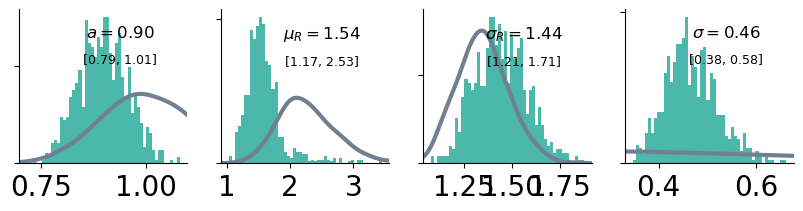

In [48]:
fig, axs = plt.subplots(1, 4, figsize=(10, 2))

cov19.plot.distribution(R_model, R_trace, 'a', dist_math='a', ax=axs[0])
cov19.plot.distribution(R_model, R_trace, 'mu_R', dist_math='\mu_R', ax=axs[1])
cov19.plot.distribution(R_model, R_trace, 'sigma_R', dist_math='\sigma_R', ax=axs[2])
cov19.plot.distribution(R_model, R_trace, 'sigma', dist_math='\sigma', ax=axs[3])

fig.savefig(f"figures/{tag}_distributions.png", dpi=300, bbox_inches="tight")

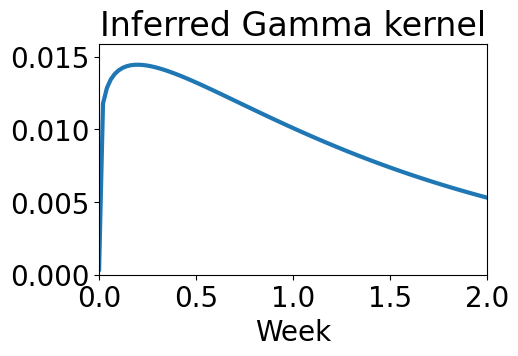

In [49]:
# plot Gamma distribution with inferred mean and standard deviation
fig, ax = plt.subplots(1, 1, figsize=(5, 3))
max_x = 2
x = np.linspace(0, max_x, 100)
y = cov19.model._utility.tt_gamma(x, mu=np.median(R_trace.posterior['mu_R']), sigma=np.median(R_trace.posterior['sigma_R'])).eval()
ax.plot(x, y, linewidth=3)
ax.set_xlabel("Week")
ax.set_title("Inferred Gamma kernel")
ax.set_xlim(0, max_x)
ax.set_ylim(0, 1.1*np.max(y))
fig.savefig(f"figures/{tag}_gamma_kernel.png", dpi=300, bbox_inches="tight")

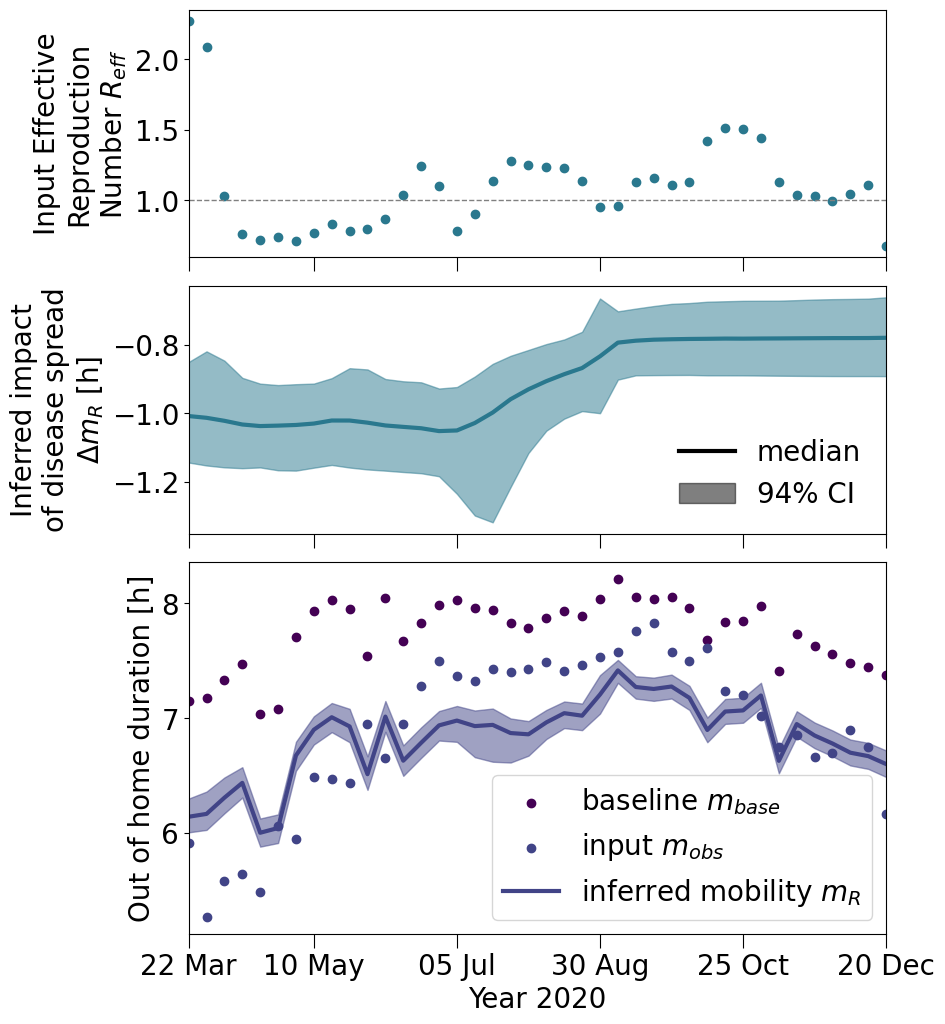

In [50]:
fig, axs = plt.subplots(3, 1, figsize=(9, 12), height_ratios=[2, 2, 3], sharex=True)

# upper plot
ax = axs[0]
ax.scatter(dates, R_trace.constant_data["R_eff"], color=color_R)
ax.hlines(1, dates[0], dates[-1], linestyle="--", color="grey", linewidth=1)
ax.set_ylabel(f"Input Effective\nReproduction\nNumber $R_{{eff}}$")
format_x_axis(ax, dates)

# middle plot
ax = axs[1]
plot_timeseries(ax, dates, R_trace.posterior['del_m_R'], "inferred impact of disease spread $\Delta m_R$", color_del_m_R)
format_x_axis(ax, dates)
# set y label
ax.set_ylabel("Inferred impact\nof disease spread\n$\Delta m_R$ [h]")
# create custom legend
## for median line and 94% CI
median_line = lines.Line2D([], [], color='black', linewidth=3, label="median")
ci_94 = patches.Patch(color='black', alpha=0.5, label="94% CI")
## create legend
legend = ax.legend(handles=[median_line, ci_94], loc="lower right", frameon=False)

# lower plot
ax = axs[2]
ax.scatter(dates, R_trace.constant_data["m_base"], label="baseline $m_{base}$", color=color_m_base)
ax.scatter(dates, R_trace.observed_data["likelihood"], label="input $m_{obs}$", color=color_m_obs)
plot_timeseries(ax, dates, R_trace.posterior['m_R'], "inferred mobility $m_R$", color_m_obs)
ax.legend()
format_x_axis(ax, dates, last=True)
# set y label
ax.set_ylabel("Out of home duration [h]")

plt.subplots_adjust(hspace=0.1)

# save figure
plt.savefig(f"figures/overview_{tag}.png", bbox_inches="tight")

## ICU

In [ ]:
# load trace from file
tag = "ICU_model_test"
path = f"results/raw/trace_{tag}.pickle"
with open(path, "rb") as inference_file:
    ICU_trace = pickle.load(inference_file)

In [33]:
az.summary(ICU_trace)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
b,0.018,0.003,0.012,0.023,0.000,0.000,699.0,280.0,1.02
mu_ICU,1.430,0.368,0.727,2.064,0.017,0.012,498.0,425.0,1.01
sigma_ICU,1.721,0.171,1.405,2.040,0.008,0.006,421.0,464.0,1.01
sigma,0.723,0.099,0.558,0.914,0.005,0.004,423.0,370.0,1.01
del_m_ICU[0],-0.289,0.047,-0.381,-0.204,0.002,0.001,691.0,338.0,1.01
...,...,...,...,...,...,...,...,...,...
m_ICU[35],6.739,0.142,6.475,7.007,0.005,0.004,710.0,293.0,1.02
m_ICU[36],6.669,0.142,6.401,6.934,0.005,0.004,709.0,293.0,1.02
m_ICU[37],6.590,0.142,6.321,6.854,0.005,0.004,708.0,293.0,1.02
m_ICU[38],6.560,0.142,6.291,6.825,0.005,0.004,707.0,293.0,1.02


(0.0, 1.0755564511121483)

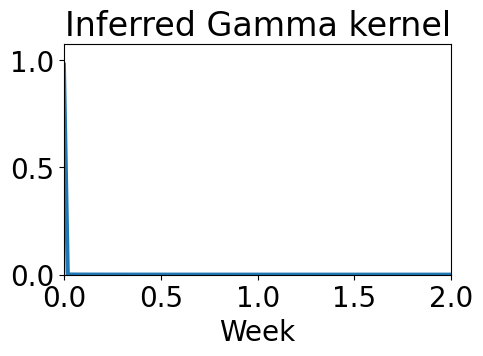

In [34]:
# plot Gamma distribution with inferred mean and standard deviation
fig, ax = plt.subplots(1, 1, figsize=(5, 3))
max_x = 2
x = np.linspace(0, max_x, 100)
y = cov19.model._utility.tt_gamma(x, mu=np.median(ICU_trace.posterior['mu_ICU']), sigma=np.median(ICU_trace.posterior['sigma_ICU'])).eval()
ax.plot(x, y, linewidth=3)
ax.set_xlabel("Week")
ax.set_title("Inferred Gamma kernel")
ax.set_xlim(0, max_x)
ax.set_ylim(0, 1.1*np.max(y))

Sampling: [b]
INFO     [pymc] Sampling: [b]
Sampling: [mu_ICU]
INFO     [pymc] Sampling: [mu_ICU]
Sampling: [sigma_ICU]
INFO     [pymc] Sampling: [sigma_ICU]
Sampling: [sigma]
INFO     [pymc] Sampling: [sigma]


[<Axes: >]

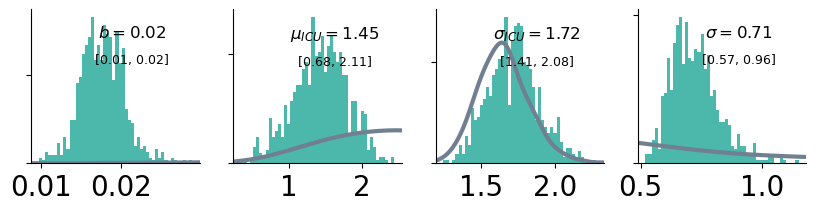

In [35]:
fig, axs = plt.subplots(1, 4, figsize=(10, 2))

cov19.plot.distribution(ICU_model, ICU_trace, 'b', dist_math='b', ax=axs[0])
cov19.plot.distribution(ICU_model, ICU_trace, 'mu_ICU', dist_math='\mu_{ICU}', ax=axs[1])
cov19.plot.distribution(ICU_model, ICU_trace, 'sigma_ICU', dist_math='\sigma_{ICU}', ax=axs[2])
cov19.plot.distribution(ICU_model, ICU_trace, 'sigma', dist_math='\sigma', ax=axs[3])

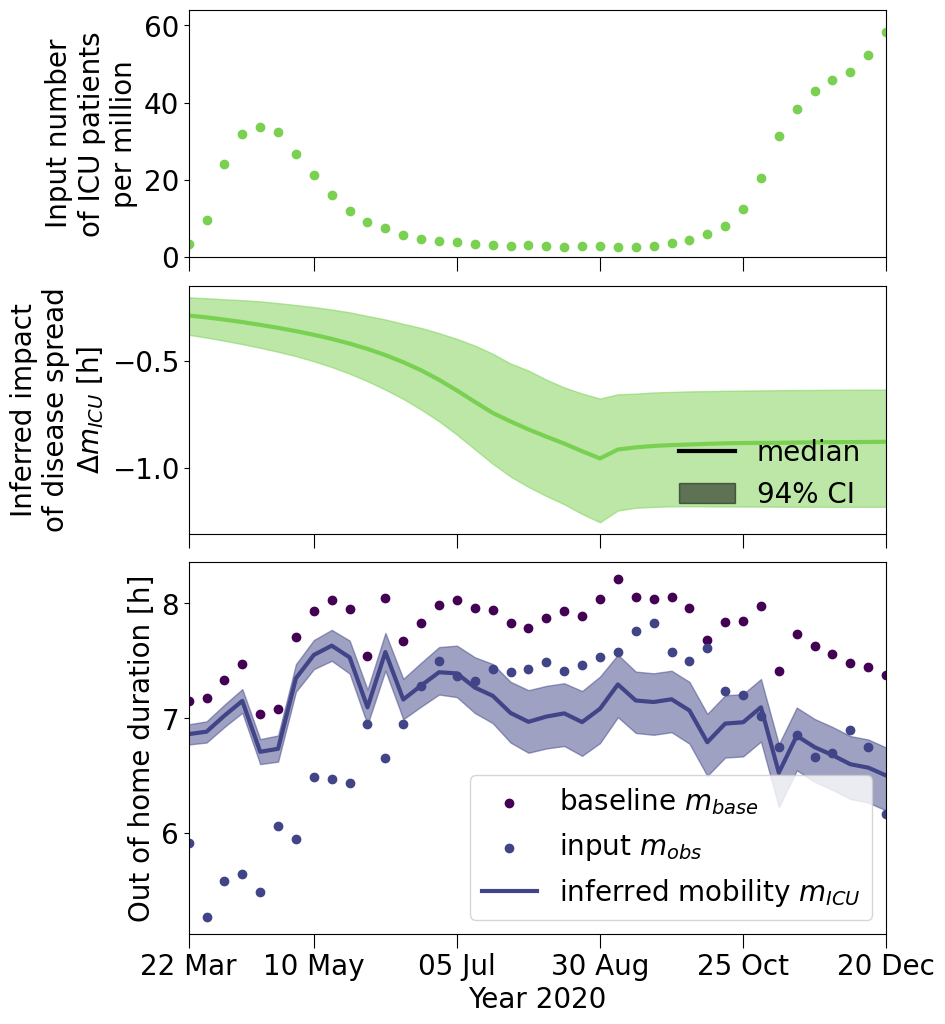

In [37]:
fig, axs = plt.subplots(3, 1, figsize=(9, 12), height_ratios=[2, 2, 3], sharex=True)

# upper plot
ax = axs[0]
ax.scatter(dates, ICU_trace.constant_data["ICU"], color=color_ICU)
ax.set_ylabel(f"Input number\nof ICU patients\nper million")
ax.set_ylim(0, 1.1 * ICU_trace.constant_data["ICU"].max())
format_x_axis(ax, dates)

# middle plot
ax = axs[1]
#ax.plot(mobility_df_2020["week"], mobility_df_2022["outOfHomeDuration"], label="2022", linewidth=3, color=color_m, linestyle="--")
plot_timeseries(ax, dates, ICU_trace.posterior['del_m_ICU'], "inferred impact of disease spread $\Delta m_ICU$", color_del_m_ICU)
format_x_axis(ax, dates)
# set y label
ax.set_ylabel("Inferred impact\nof disease spread\n$\Delta m_{ICU}$ [h]")
# create custom legend
## for median line and 94% CI
median_line = lines.Line2D([], [], color='black', linewidth=3, label="median")
ci_94 = patches.Patch(color='black', alpha=0.5, label="94% CI")
## create legend
legend = ax.legend(handles=[median_line, ci_94], loc="lower right", frameon=False)

# lower plot
ax = axs[2]
ax.scatter(dates, ICU_trace.constant_data["m_base"], label="baseline $m_{base}$", color=color_m_base)
ax.scatter(dates, ICU_trace.observed_data["likelihood"], label="input $m_{obs}$", color=color_m_obs)
plot_timeseries(ax, dates, ICU_trace.posterior['m_ICU'], "inferred mobility $m_{ICU}$", color_m)
ax.legend()
format_x_axis(ax, dates, last=True)
# set y label
ax.set_ylabel("Out of home duration [h]")

plt.subplots_adjust(hspace=0.1)

# save figure
plt.savefig(f"figures/overview_{tag}.png", bbox_inches="tight")

## R + cases model

In [82]:
az.summary(RC_trace)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
a,0.892,0.075,0.760,1.034,0.003,0.002,549.0,539.0,1.0
c,-0.001,0.000,-0.001,0.000,0.000,0.000,507.0,525.0,1.0
mu_R,1.569,0.242,1.135,1.990,0.012,0.009,534.0,326.0,1.0
sigma_R,1.475,0.135,1.217,1.717,0.005,0.004,721.0,641.0,1.0
mu_ICU,2.269,0.430,1.420,3.017,0.015,0.011,786.0,553.0,1.0
...,...,...,...,...,...,...,...,...,...
m[35],7.016,0.101,6.845,7.215,0.003,0.002,840.0,559.0,1.0
m[36],6.946,0.101,6.775,7.146,0.003,0.002,841.0,580.0,1.0
m[37],6.866,0.100,6.695,7.067,0.003,0.002,841.0,628.0,1.0
m[38],6.834,0.100,6.661,7.035,0.003,0.002,828.0,628.0,1.0


Sampling: [a]
INFO     [pymc] Sampling: [a]
Sampling: [mu_R]
INFO     [pymc] Sampling: [mu_R]
Sampling: [sigma_R]
INFO     [pymc] Sampling: [sigma_R]
Sampling: [c]
INFO     [pymc] Sampling: [c]
Sampling: [mu_C]
INFO     [pymc] Sampling: [mu_C]
Sampling: [sigma_C]
INFO     [pymc] Sampling: [sigma_C]
Sampling: [sigma]
INFO     [pymc] Sampling: [sigma]
Sampling: [sigma]
INFO     [pymc] Sampling: [sigma]


[<Axes: >]

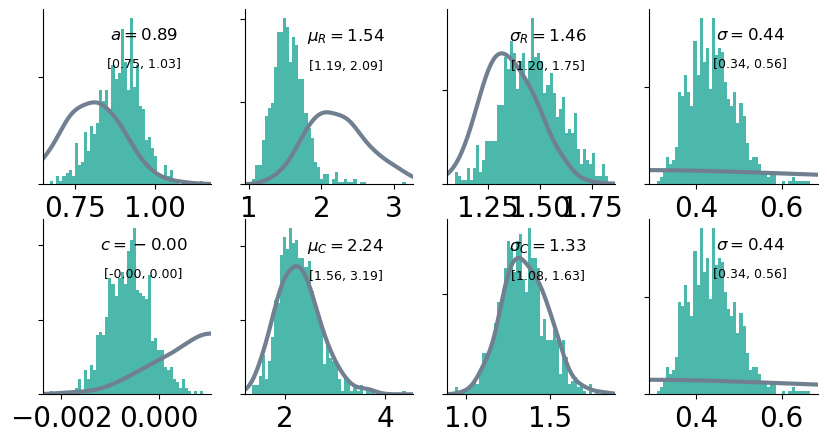

In [86]:
fig, axs = plt.subplots(2, 4, figsize=(10, 5))

cov19.plot.distribution(RC_model, RC_trace, 'a', dist_math='a', ax=axs[0,0])
cov19.plot.distribution(RC_model, RC_trace, 'mu_R', dist_math='\mu_R', ax=axs[0,1])
cov19.plot.distribution(RC_model, RC_trace, 'sigma_R', dist_math='\sigma_R', ax=axs[0,2])
cov19.plot.distribution(RC_model, RC_trace, 'c', dist_math='c', ax=axs[1,0])
cov19.plot.distribution(RC_model, RC_trace, 'mu_C', dist_math='\mu_{C}', ax=axs[1,1])
cov19.plot.distribution(RC_model, RC_trace, 'sigma_C', dist_math='\sigma_{C}', ax=axs[1,2])
cov19.plot.distribution(RC_model, RC_trace, 'sigma', dist_math='\sigma', ax=axs[0,3])
cov19.plot.distribution(RC_model, RC_trace, 'sigma', dist_math='\sigma', ax=axs[1,3])

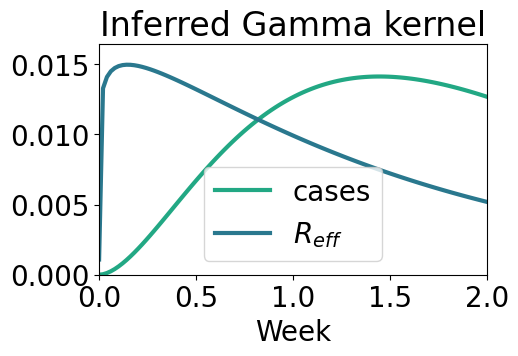

In [89]:
# plot Gamma distribution with inferred mean and standard deviation
fig, ax = plt.subplots(1, 1, figsize=(5, 3))
max_x = 2
x = np.linspace(0, max_x, 100)
y = cov19.model._utility.tt_gamma(x, mu=np.median(RC_trace.posterior['mu_C']), sigma=np.median(RC_trace.posterior['sigma_C'])).eval()
ax.plot(x, y, linewidth=3, label="cases", color=color_C)
z = cov19.model._utility.tt_gamma(x, mu=np.median(RC_trace.posterior['mu_R']), sigma=np.median(RC_trace.posterior['sigma_R'])).eval()
ax.plot(x, z, linewidth=3, label="$R_{eff}$", color=color_R)
ax.set_xlabel("Week")
ax.set_title("Inferred Gamma kernel")
ax.set_xlim(0, max_x)
ax.set_ylim(0, 1.1*np.max((np.max(y), np.max(z))))
ax.legend()

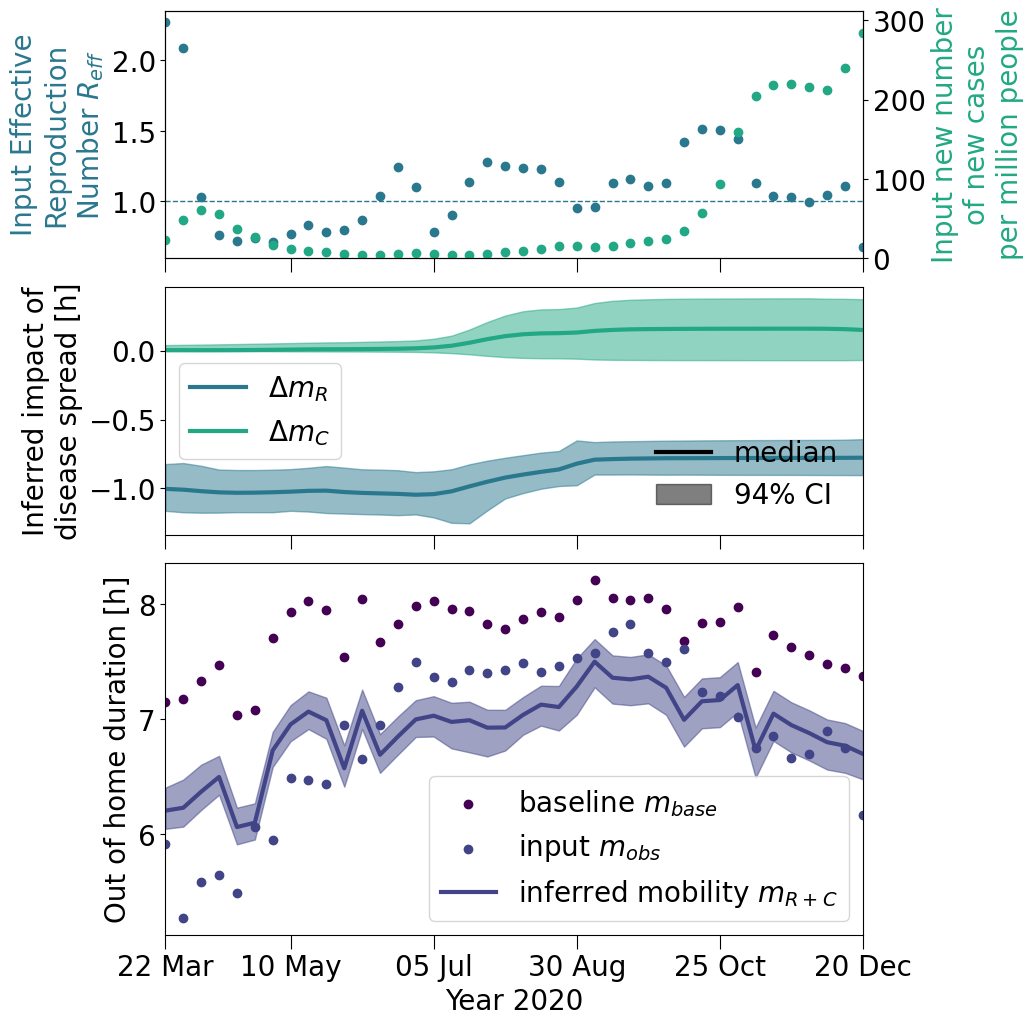

In [92]:
fig, axs = plt.subplots(3, 1, figsize=(9, 12), height_ratios=[2, 2, 3], sharex=True)

trace = RC_trace

# upper plot
ax = axs[0]
ax.scatter(dates, trace.constant_data["R_eff"], color=color_R)
ax.hlines(1, dates[0], dates[-1], linestyle="--", color=color_R, linewidth=1)
ax.set_ylabel(f"Input Effective\nReproduction\nNumber $R_{{eff}}$", color=color_R)
ax_ICU = ax.twinx()
ax_ICU.scatter(dates, trace.constant_data["cases"], color=color_C)
ax_ICU.set_ylabel(f"Input new number\nof new cases\nper million people", color=color_C)
ax_ICU.set_ylim(0, 1.1 * trace.constant_data["cases"].max())
format_x_axis(ax, dates)

# middle plot
ax = axs[1]
plot_timeseries(ax, 
                dates, 
                trace.posterior['del_m_R'], 
                color_in=color_del_m_R,
                label_in="$\Delta m_R$",
                )
plot_timeseries(ax, 
                dates, 
                trace.posterior['del_m_C'], 
                color_in=color_del_m_C,
                label_in="$\Delta m_{C}$")
format_x_axis(ax, dates)
# set y label
ax.set_ylabel("Inferred impact of\ndisease spread [h]")
legend1 = ax.legend()
ax.add_artist(legend1)
# create custom legend
## for median line and 94% CI
median_line = lines.Line2D([], [], color='black', linewidth=3, label="median")
ci_94 = patches.Patch(color='black', alpha=0.5, label="94% CI")
## create legend
legend2 = ax.legend(handles=[median_line, ci_94], loc="lower right", frameon=False)
#ax.add_artist(legend2)

# lower plot
ax = axs[2]
ax.scatter(dates, trace.constant_data["m_base"], label="baseline $m_{base}$", color=color_m_base)
ax.scatter(dates, trace.observed_data["likelihood"], label="input $m_{obs}$", color=color_m_obs)
plot_timeseries(ax, dates, joint_trace.posterior['m'], "inferred mobility $m_{R+C}$", color_m)
ax.legend()
format_x_axis(ax, dates, last=True)
# set y label
ax.set_ylabel("Out of home duration [h]")

plt.subplots_adjust(hspace=0.1)

# save figure
plt.savefig(f"figures/overview_{tag}.png", bbox_inches="tight")

## R + ICU model

In [54]:
az.summary(joint_trace)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
a,0.850,0.084,0.693,1.006,0.004,0.003,499.0,409.0,1.00
b,-0.001,0.003,-0.006,0.004,0.000,0.000,549.0,447.0,1.00
mu_R,1.637,0.336,1.099,2.299,0.021,0.015,371.0,285.0,1.00
sigma_R,1.442,0.141,1.180,1.693,0.006,0.004,645.0,536.0,1.01
mu_ICU,2.251,0.458,1.493,3.217,0.015,0.011,876.0,736.0,1.00
...,...,...,...,...,...,...,...,...,...
m[35],6.945,0.111,6.741,7.172,0.003,0.002,1027.0,623.0,1.01
m[36],6.875,0.111,6.671,7.102,0.003,0.002,1027.0,623.0,1.01
m[37],6.795,0.111,6.592,7.021,0.003,0.002,1032.0,622.0,1.01
m[38],6.766,0.110,6.563,6.991,0.003,0.002,1040.0,648.0,1.01


Sampling: [a]
INFO     [pymc] Sampling: [a]
Sampling: [mu_R]
INFO     [pymc] Sampling: [mu_R]
Sampling: [sigma_R]
INFO     [pymc] Sampling: [sigma_R]
Sampling: [b]
INFO     [pymc] Sampling: [b]
Sampling: [mu_ICU]
INFO     [pymc] Sampling: [mu_ICU]
Sampling: [sigma_ICU]
INFO     [pymc] Sampling: [sigma_ICU]
Sampling: [sigma]
INFO     [pymc] Sampling: [sigma]
Sampling: [sigma]
INFO     [pymc] Sampling: [sigma]


[<Axes: >]

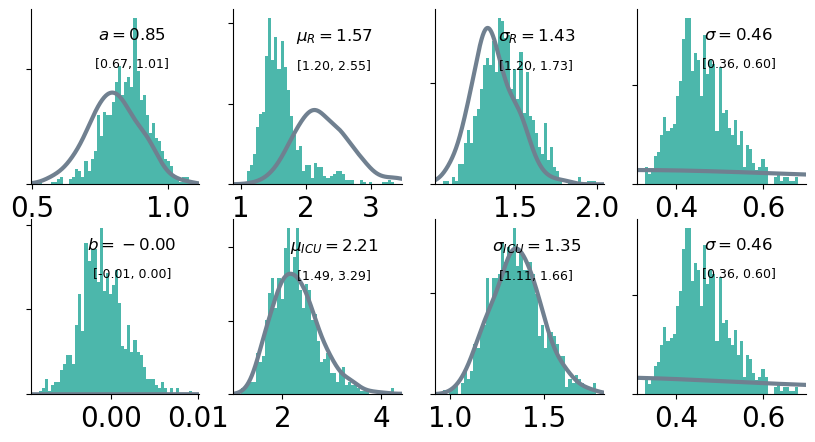

In [55]:
fig, axs = plt.subplots(2, 4, figsize=(10, 5))

cov19.plot.distribution(joint_model, joint_trace, 'a', dist_math='a', ax=axs[0,0])
cov19.plot.distribution(joint_model, joint_trace, 'mu_R', dist_math='\mu_R', ax=axs[0,1])
cov19.plot.distribution(joint_model, joint_trace, 'sigma_R', dist_math='\sigma_R', ax=axs[0,2])
cov19.plot.distribution(joint_model, joint_trace, 'b', dist_math='b', ax=axs[1,0])
cov19.plot.distribution(joint_model, joint_trace, 'mu_ICU', dist_math='\mu_{ICU}', ax=axs[1,1])
cov19.plot.distribution(joint_model, joint_trace, 'sigma_ICU', dist_math='\sigma_{ICU}', ax=axs[1,2])
cov19.plot.distribution(joint_model, joint_trace, 'sigma', dist_math='\sigma', ax=axs[0,3])
cov19.plot.distribution(joint_model, joint_trace, 'sigma', dist_math='\sigma', ax=axs[1,3])

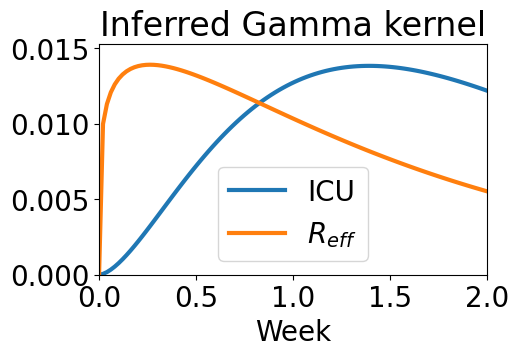

In [56]:
# plot Gamma distribution with inferred mean and standard deviation
fig, ax = plt.subplots(1, 1, figsize=(5, 3))
max_x = 2
x = np.linspace(0, max_x, 100)
y = cov19.model._utility.tt_gamma(x, mu=np.median(joint_trace.posterior['mu_ICU']), sigma=np.median(joint_trace.posterior['sigma_ICU'])).eval()
ax.plot(x, y, linewidth=3, label="ICU")
z = cov19.model._utility.tt_gamma(x, mu=np.median(joint_trace.posterior['mu_R']), sigma=np.median(joint_trace.posterior['sigma_R'])).eval()
ax.plot(x, z, linewidth=3, label="$R_{eff}$")
ax.set_xlabel("Week")
ax.set_title("Inferred Gamma kernel")
ax.set_xlim(0, max_x)
ax.set_ylim(0, 1.1*np.max((np.max(y), np.max(z))))
ax.legend()

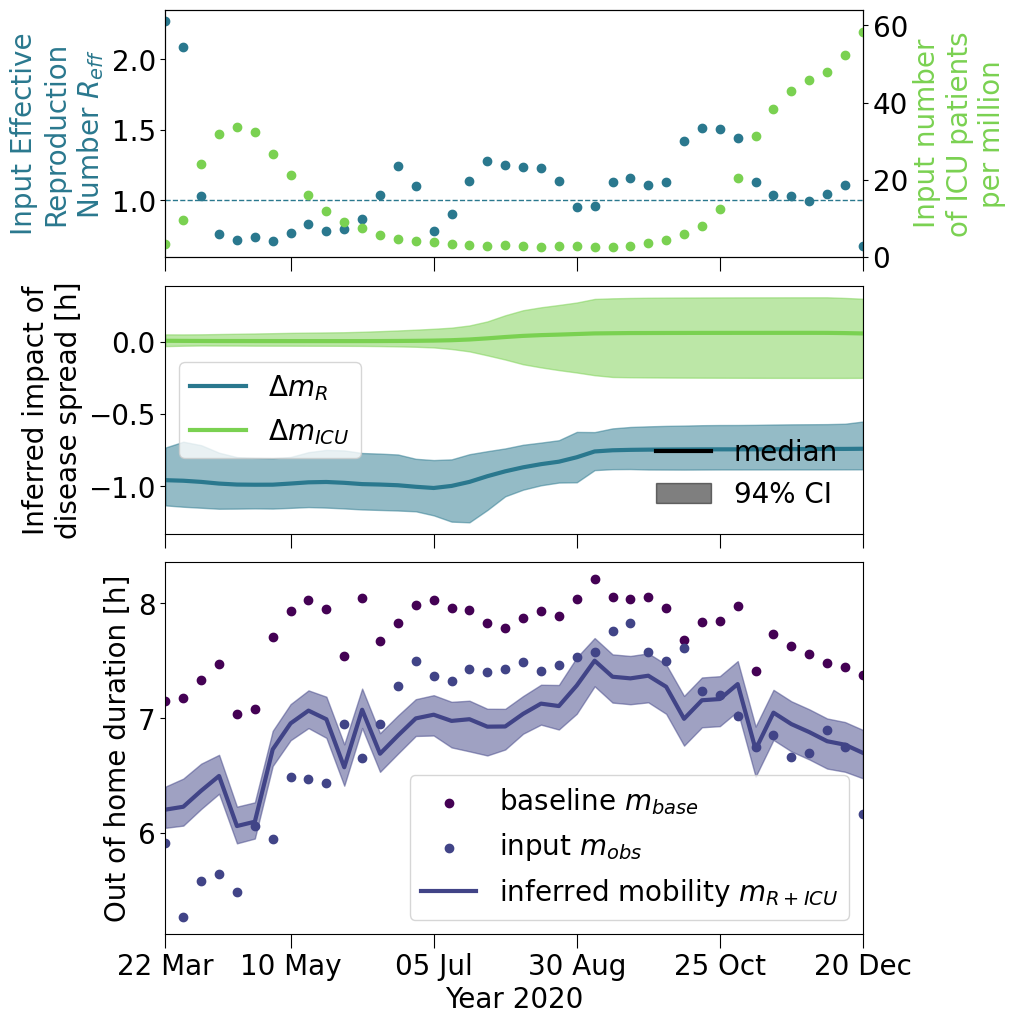

In [58]:
fig, axs = plt.subplots(3, 1, figsize=(9, 12), height_ratios=[2, 2, 3], sharex=True)

# upper plot
ax = axs[0]
ax.scatter(dates, joint_trace.constant_data["R_eff"], color=color_R)
ax.hlines(1, dates[0], dates[-1], linestyle="--", color=color_R, linewidth=1)
ax.set_ylabel(f"Input Effective\nReproduction\nNumber $R_{{eff}}$", color=color_R)
ax_ICU = ax.twinx()
ax_ICU.scatter(dates, joint_trace.constant_data["ICU"], color=color_ICU)
ax_ICU.set_ylabel(f"Input number\nof ICU patients\nper million", color=color_ICU)
ax_ICU.set_ylim(0, 1.1 * joint_trace.constant_data["ICU"].max())
format_x_axis(ax, dates)

# middle plot
ax = axs[1]
plot_timeseries(ax, 
                dates, 
                joint_trace.posterior['del_m_R'], 
                color_in=color_del_m_R,
                label_in="$\Delta m_R$",
                )
plot_timeseries(ax, 
                dates, 
                joint_trace.posterior['del_m_ICU'], 
                color_in=color_del_m_ICU,
                label_in="$\Delta m_{ICU}$")
format_x_axis(ax, dates)
# set y label
ax.set_ylabel("Inferred impact of\ndisease spread [h]")
legend1 = ax.legend()
ax.add_artist(legend1)
# create custom legend
## for median line and 94% CI
median_line = lines.Line2D([], [], color='black', linewidth=3, label="median")
ci_94 = patches.Patch(color='black', alpha=0.5, label="94% CI")
## create legend
legend2 = ax.legend(handles=[median_line, ci_94], loc="lower right", frameon=False)
#ax.add_artist(legend2)

# lower plot
ax = axs[2]
ax.scatter(dates, joint_trace.constant_data["m_base"], label="baseline $m_{base}$", color=color_m_base)
ax.scatter(dates, joint_trace.observed_data["likelihood"], label="input $m_{obs}$", color=color_m_obs)
plot_timeseries(ax, dates, joint_trace.posterior['m'], "inferred mobility $m_{R+ICU}$", color_m)
ax.legend()
format_x_axis(ax, dates, last=True)
# set y label
ax.set_ylabel("Out of home duration [h]")

plt.subplots_adjust(hspace=0.1)

# save figure
plt.savefig(f"figures/overview_{tag}.png", bbox_inches="tight")

## Comparison

In [59]:
with C_model:
    pm.compute_log_likelihood(C_trace)

ValueError: ['log_likelihood'] group(s) already exists.

In [61]:
with ICU_model:
    pm.compute_log_likelihood(ICU_trace)

ValueError: ['log_likelihood'] group(s) already exists.

In [66]:
with joint_model:
    pm.compute_log_likelihood(joint_trace)

In [119]:
with R_model:
    pm.compute_log_likelihood(R_trace)

In [94]:
with RC_model:
    pm.compute_log_likelihood(RC_trace)

In [95]:
az.compare({
    "R + ICU": joint_trace, 
    "R": R_trace, 
    "ICU": ICU_trace,
    "C": C_trace,
    "R + C": RC_trace,
    }, ic="loo")

,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
R + C,0,-24.597116,1.966919,0.000000,1.000000e+00,3.342230,0.000000,False,log
R,1,-26.526049,1.407933,1.928932,8.604784e-13,2.936055,1.257719,False,log
R + ICU,2,-26.684468,2.111944,2.087352,6.686318e-13,3.383688,0.543027,False,log
ICU,3,-45.135040,1.999523,20.537924,0.000000e+00,4.671886,2.620710,False,log
C,4,-45.302304,1.659909,20.705188,0.000000e+00,5.018437,2.911941,False,log


In [97]:
az.compare({
    "R + ICU": joint_trace, 
    "R": R_trace, 
    "ICU": ICU_trace,
    "C": C_trace,
    "R + C": RC_trace,
    }, ic="waic")

,rank,elpd_waic,p_waic,elpd_diff,weight,se,dse,warning,scale
R + C,0,-24.566812,1.936615,0.000000,1.000000e+00,3.335684,0.000000,False,log
R,1,-26.505541,1.387425,1.938729,0.000000e+00,2.931539,1.255529,False,log
R + ICU,2,-26.652727,2.080203,2.085915,0.000000e+00,3.376680,0.541364,False,log
ICU,3,-45.121637,1.986120,20.554825,2.520206e-14,4.669819,2.619374,False,log
C,4,-45.280859,1.638463,20.714047,1.889044e-12,5.011705,2.909210,False,log
